In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
                              
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = "cpu"


In [2]:
torch.__version__

'2.4.1'

In [3]:
torch.__config__.show()

'PyTorch built with:\n  - GCC 12.4\n  - C++ Version: 201703\n  - Intel(R) oneAPI Math Kernel Library Version 2024.2.2-Product Build 20240823 for Intel(R) 64 architecture applications\n  - OpenMP 201511 (a.k.a. OpenMP 4.5)\n  - LAPACK is enabled (usually provided by MKL)\n  - NNPACK is enabled\n  - CPU capability usage: AVX2\n  - CUDA Runtime 12.1\n  - Built with CUDA Runtime 12.0\n  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gencode;arch=compute_61,code=sm_61;-gencode;arch=compute_70,code=sm_70;-gencode;arch=compute_75,code=sm_75;-gencode;arch=compute_80,code=sm_80;-gencode;arch=compute_86,code=sm_86;-gencode;arch=compute_89,code=sm_89;-gencode;arch=compute_90,code=sm_90;-gencode;arch=compute_90,code=compute_90\n  - CuDNN 91.0.2  (built against CUDA 12.9)\n    - Built with CuDNN 90.8\n  - Magma 2.8.0\n  - Build settings: BLAS_INFO=mkl, BUILD_TYPE=Release, CUDA_VERSION=12.0, CUDNN_VERSION=9.8.0, CXX_COMPILER=/home/conda/feedstock_

### Choose model for attribution

In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer
# Choose tokenizer and model

# model_name = "meta-llama/Llama-3.2-1B"
# model_name = "meta-llama/Llama-3.2-3B"
# model_name = "Qwen/Qwen2.5-3B"
model_name = "Qwen/Qwen2.5-1.5B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
if device.type == "cpu":
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

/home/jl3499/conda/LLM1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jl3499/conda/LLM1/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [4]:
front_pad = 2

### Select scope type

In [5]:
# mode = 'Temperature'
# mode = 'Semantic'
mode = 'Fisher'

### Set attribution prompt

In [6]:
string = "Italian: Buon pomeriggio, i miei colleghi ricercatori. English: Good afternoon, my fellow researchers"
string = "German: Dies ist ein Aufsatz über kausale Zuschreibung. English: This is a paper on causal attribution"
# string = "French: Nous l'appelons lentille jacobienne. English: We call it Jacobian Scope"

### Perform attribution

In [7]:
import JacobianScopes
scores, logits, decoded_tokens, grad_idx, loss_position = JacobianScopes.run_scope(model, 
                                                                                   tokenizer, 
                                                                                   string, 
                                                                                   mode, 
                                                                                   front_pad=2, 
                                                                                   loss_position=-2, 
                                                                                   device=device)
    

### Visualize prediction

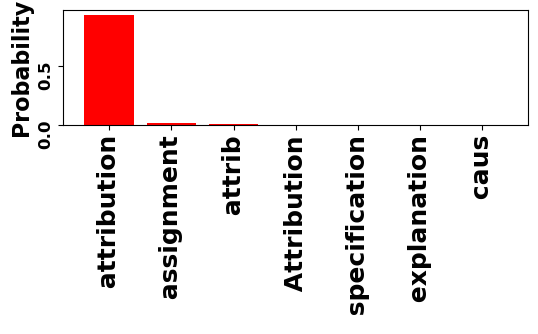

In [8]:

logit_vector = logits[loss_position].detach()             
# Compute softmax probabilities
probs = torch.softmax(logit_vector, dim=-1)
JacobianScopes.natural_language_pred_plotter(probs, tokenizer, k = 7)

### Visualize attribution

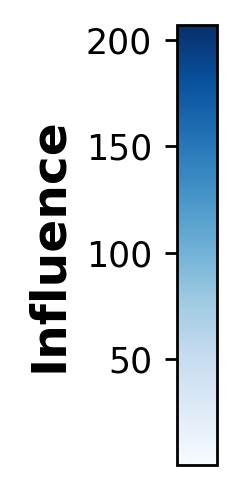

In [9]:

JacobianScopes.natural_language_attribution_plotter(decoded_tokens, grad_idx, scores, mode, loss_position, style = 'B' )